# GPPlus Basic Usage

In [ ]:
# Import needed libraries
import logging

import gpytorch
import matplotlib.pyplot as plt
import torch

import gpplus
from gpplus.config import configure_logger
from gpplus.training import ConvergencePatienceStopCondition, GPTrainer, MinLossChangeStopCondition

configure_logger(logging.WARNING)

## 1. Define a toy dataset

In [ ]:
train_x = torch.linspace(0, 1, 10)
train_y = torch.sin(train_x * (2 * torch.pi)) + 0.1 * torch.randn(train_x.size())

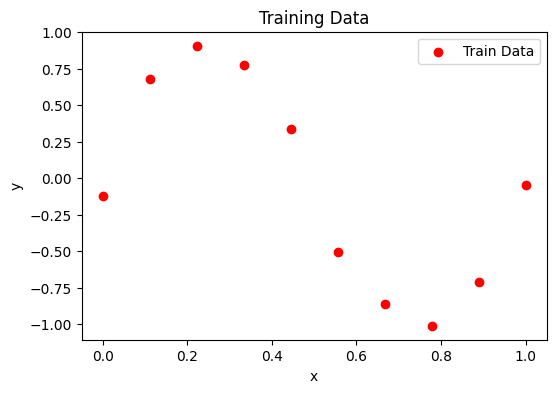

In [ ]:
# Plot the training data
plt.figure(figsize=(6, 4))
plt.scatter(train_x.numpy(), train_y.numpy(), color="red", label="Train Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training Data")
plt.legend()
plt.show()

## 2. Define the GP model and likelihood

In [ ]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = gpplus.models.GPR(train_x, train_y, likelihood)

[2025-04-07 15:09:39] gpplus - WARNING: No mean_module provided. Using ConstantMean as default.
[2025-04-07 15:09:39] gpplus - WARNING: No kernel_module provided. Using Gaussian Kernel as default.


## 3. Train the model

[2025-04-07 15:09:39] gpplus - WARNING: Using device cuda, only 1 run is allowed.
Epoch 0 - Loss: 51.3930
Epoch 1 - Loss: 2.8561
Epoch 2 - Loss: 1.2404
Epoch 3 - Loss: 1.1480
Epoch 4 - Loss: 0.8465
Epoch 5 - Loss: 0.2710
Epoch 6 - Loss: 0.2473
Epoch 7 - Loss: 0.2371
Epoch 8 - Loss: 0.2325
Epoch 9 - Loss: 0.2322
Epoch 10 - Loss: 0.2322
Epoch 11 - Loss: 0.2322
Epoch 12 - Loss: 0.2322
Epoch 13 - Loss: 0.2322
Epoch 14 - Loss: 0.2322
Epoch 15 - Loss: 0.2322
Epoch 16 - Loss: 0.2322
Epoch 17 - Loss: 0.2322
Epoch 18 - Loss: 0.2322
Epoch 19 - Loss: 0.2322
Epoch 20 - Loss: 0.2322
Epoch 21 - Loss: 0.2322
Epoch 22 - Loss: 0.2322
Epoch 23 - Loss: 0.2322
Epoch 24 - Loss: 0.2322
Epoch 25 - Loss: 0.2322
Epoch 26 - Loss: 0.2322
Epoch 27 - Loss: 0.2322
Epoch 28 - Loss: 0.2322
Epoch 29 - Loss: 0.2322
Epoch 30 - Loss: 0.2322
Epoch 31 - Loss: 0.2322
Epoch 32 - Loss: 0.2322
Epoch 33 - Loss: 0.2322
Epoch 34 - Loss: 0.2322
Epoch 35 - Loss: 0.2322
Epoch 36 - Loss: 0.2322
Epoch 37 - Loss: 0.2322
Epoch 38 - Loss

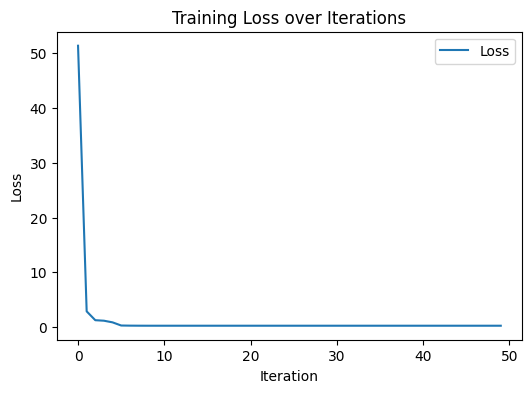

In [ ]:
training_iter = 50
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)


class PrintLossCallback(gpplus.training.callbacks.Callback):
    def on_epoch_end(self, context: dict):
        print(f"Epoch {context['epoch']} - Loss: {context['loss']:.4f}")


class LossCallback(gpplus.training.callbacks.Callback):
    def __init__(self):
        self.loss = []

    def on_epoch_end(self, context: dict):
        self.loss.append(context["loss"])


printCallback = PrintLossCallback()
lossCallback = LossCallback()
cllbcks = [printCallback, lossCallback]

trainer = GPTrainer(
    model=model,
    num_runs=1,
    callbacks=cllbcks,
    device="cuda",
    stop_conditions=[
        ConvergencePatienceStopCondition(patience=150),
        MinLossChangeStopCondition(min_loss_change=1e-7),
    ],
)
trainer.train()

# Plot training loss
plt.figure(figsize=(6, 4))
plt.plot(range(len(lossCallback.loss)), lossCallback.loss, label="Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Iterations")
plt.legend()
plt.show()

## 4. Evaluate (testing phase)

In [ ]:
model.eval()
likelihood.eval()

test_x = torch.linspace(0, 1, 51)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(model(test_x))
    mean = pred.mean
    lower, upper = pred.confidence_region()

## 5. Plot predictions

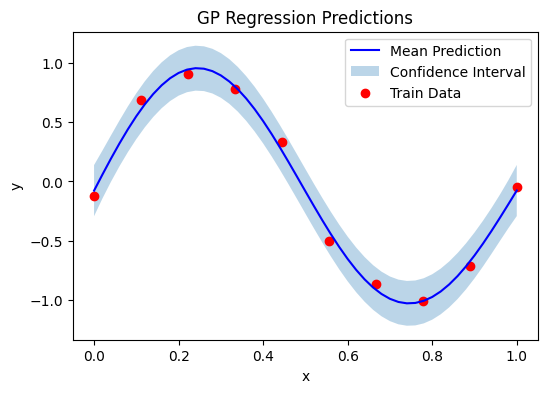


Sample Predictions:
x = 0.000 | mean = -0.078 | lower = -0.293 | upper = 0.138
x = 0.200 | mean = 0.913 | lower = 0.722 | upper = 1.104
x = 0.400 | mean = 0.508 | lower = 0.320 | upper = 0.696
x = 0.600 | mean = -0.652 | lower = -0.840 | upper = -0.464
x = 0.800 | mean = -0.971 | lower = -1.162 | upper = -0.780
x = 1.000 | mean = -0.076 | lower = -0.291 | upper = 0.139


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(test_x.numpy(), mean.numpy(), "b", label="Mean Prediction")
plt.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.3, label="Confidence Interval")
plt.scatter(train_x.numpy(), train_y.numpy(), color="red", label="Train Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("GP Regression Predictions")
plt.legend()
plt.show()

# Print sample predictions
print("\nSample Predictions:")
for i in range(0, len(test_x), 10):
    print(
        f"x = {test_x[i].item():.3f} | mean = {mean[i].item():.3f} | "
        f"lower = {lower[i].item():.3f} | "
        f"upper = {upper[i].item():.3f}"
    )